# Deconvolve the replicating timing for the 10k bin curves using the Haar wavelet for a step-wise result

April 30, 2024

Compute the replicating timing from the deconvolved MNase-seq 10k windows for each gene.

**Goal:** Deconvolve the replication timing such that the result is a step-wise function
from G1 of copy number 1, S-phase (transition from 1 to 2 step-wise), and G2M as copy number 2.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
from src.mnase_replication_timing_analysis import MNaseOriginAnalysis

mnase_analysis_rep1 = MNaseOriginAnalysis(replicate=1)
mnase_analysis_rep1.compute_bin_curves()
mnase_analysis_rep1.compute_replication_timing()


1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:02:34.341


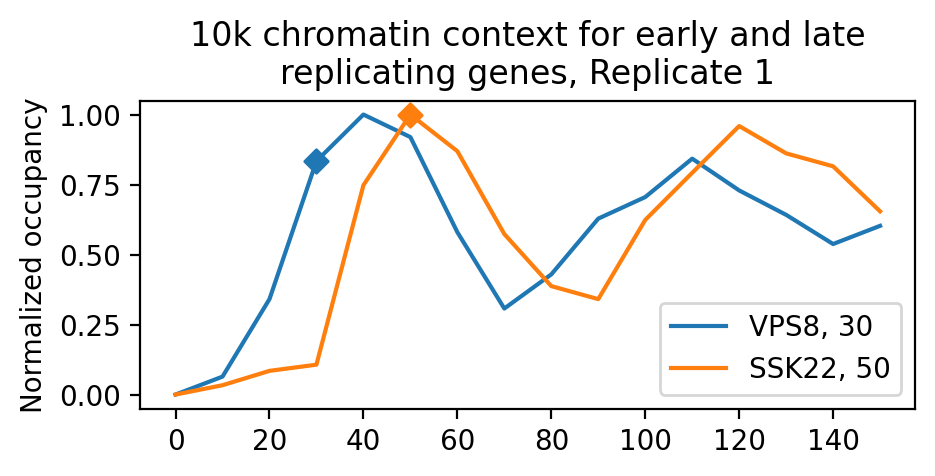

In [4]:
mnase_analysis_rep1.plot_normalized_bin_curves(['VPS8', 'SSK22'])

In [286]:
from src.sgd import get_orfname

orfname = get_orfname('VPS8')
g = mnase_analysis_rep1.normalized_bin_curves.loc[orfname].values.reshape((-1, 1))*10+10.
g.shape

(16, 1)

In [287]:
from src.dynamic_config_alpha import create_dynamic_alpha_config
from src.replication_deconvolution_solver import ReplicationChromatinDeconvolveSolver

In [343]:
config = create_dynamic_alpha_config(replicate=1, alpha=30)
solver = ReplicationChromatinDeconvolveSolver(config, g)
solver.define_deconvolution_problem()
_ = solver.solve(gamma_value=0.001, verbose=False)

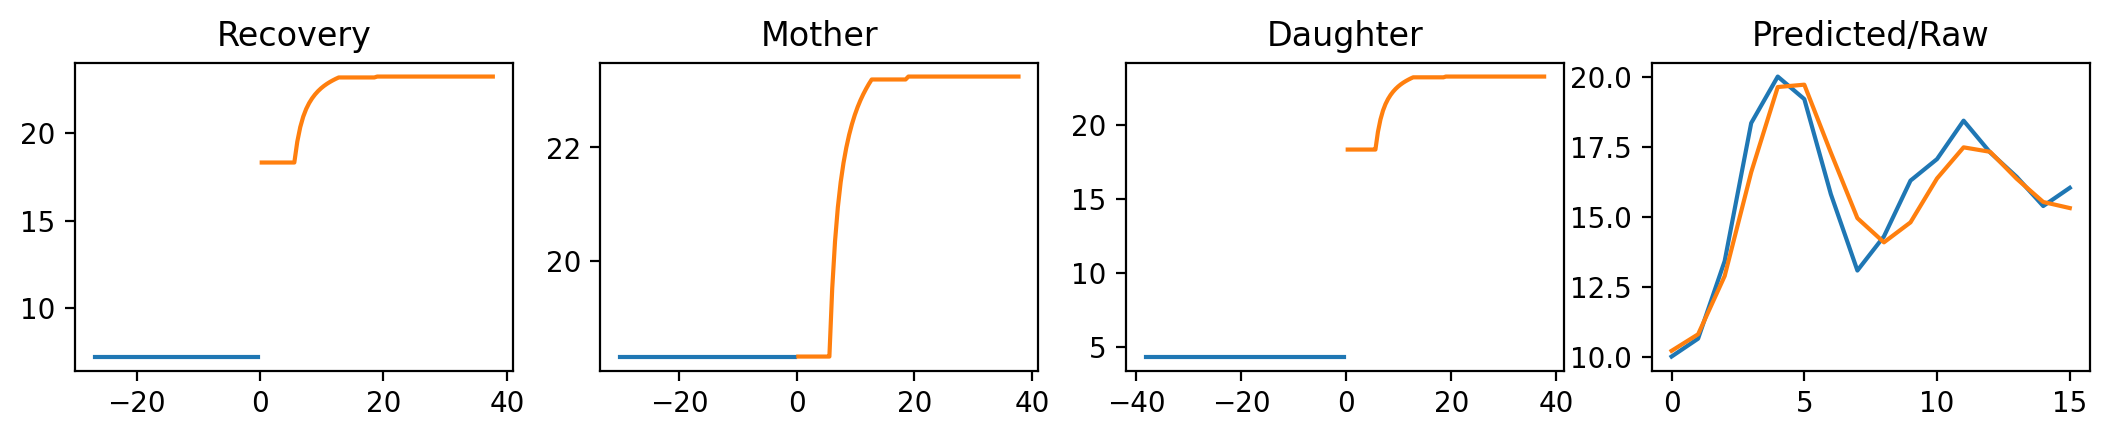

In [344]:
solver.plot_result()